In [ ]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

In [3]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. Online website
url = "https://quotes.toscrape.com/"

# 2. Read the web page
response = requests.get(url)

# 3. Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find the required tags
quotes = soup.find_all("div", class_="quote")

# 5. Extract the text
data = []

for quote in quotes:
    text = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)

    data.append({
        "Quote": text,
        "Author": author
    })

# 6. Create DataFrame
df = pd.DataFrame(data)

print(df)

# 7. Save to CSV
df.to_csv("quotes.csv", index=False)

print("Data saved to quotes.csv")

                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [5]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)
 

File read. Size: 1774012 characters


In [6]:
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break

In [7]:

 
data = json.loads(html[start:end + 1])
print("JSON loaded successfully")
 
 
# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))
 
 
# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None
 
 
def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None
 
 
rows = []
for p in properties:
    # Some listings are a price RANGE (e.g. "2.25 - 3.28 Cr").
    # We keep the minimum price, and also record the text version.
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })
 
houses = pd.DataFrame(rows)
 
# NOTE: this page also contains agent names and phone numbers.
# We deliberately do NOT collect those - that is personal data.
 
 
# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())
 
 
# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to bengaluru_houses.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  - 

In [9]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-08-14T10:30
  interval              : 900
  temperature_2m        : 25.3
  relative_humidity_2m  : 66
  wind_speed_10m        : 16.7


In [10]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-08-14 00:00:00,21.5,87,0.0
1,2026-08-14 01:00:00,21.0,89,0.0
2,2026-08-14 02:00:00,20.7,92,0.0
3,2026-08-14 03:00:00,20.5,94,0.0
4,2026-08-14 04:00:00,20.3,95,0.0


In [2]:
# --- Collect air pollution data for Bengaluru ---

# --- Collect air pollution data for Bengaluru ---

import requests
import pandas as pd
import numpy as np
from pathlib import Path

# Open-Meteo Air Quality API
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

# Bengaluru coordinates
params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7
}

try:
    # Try to get real data from the API
    r = requests.get(AQ_URL, params=params3, timeout=20)

    print("Status code:", r.status_code)

    # Check if request was successful
    r.raise_for_status()

    # Convert API response to DataFrame
    aq = pd.DataFrame(r.json()["hourly"])

    # Convert time column to datetime
    aq["time"] = pd.to_datetime(aq["time"])

    print("Real air-quality data collected successfully!")

except Exception as e:
    # If API/internet fails, create sample data
    print("API request failed.")
    print("Error:", e)
    print("Creating sample data instead...")

    # Generate 7 days × 24 hours = 168 readings
    aq = pd.DataFrame({
        "time": pd.date_range(
            start="2026-08-01",
            periods=168,
            freq="h"
        ),

        "pm2_5": np.random.uniform(20, 100, 168),

        "pm10": np.random.uniform(30, 150, 168),

        "nitrogen_dioxide": np.random.uniform(10, 80, 168),

        "ozone": np.random.uniform(20, 100, 168)
    })

# --- Save the data ---

data = Path(".")

file_path = data / "air_quality.csv"

aq.to_csv(data/"air_quality.csv", index=False)

print("\nSaved to:", data/"air_quality.csv")
print("Shape:", aq.shape)

# Display first 5 rows
aq.head()

Status code: 200
Real air-quality data collected successfully!

Saved to: air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-08-10 00:00:00,7.1,8.9,11.5,35.0
1,2026-08-10 01:00:00,6.0,7.6,9.6,34.0
2,2026-08-10 02:00:00,5.1,6.7,8.1,33.0
3,2026-08-10 03:00:00,4.5,6.2,7.0,32.0
4,2026-08-10 04:00:00,4.0,5.8,6.2,31.0


In [3]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average PM2.5: 7.3 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
dtype: int64


NameError: name 'plt' is not defined

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


Average PM2.5: 7.3 ug/m3
Highest PM2.5: 16.0 ug/m3

Missing values in each column:
time                0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
dtype: int64


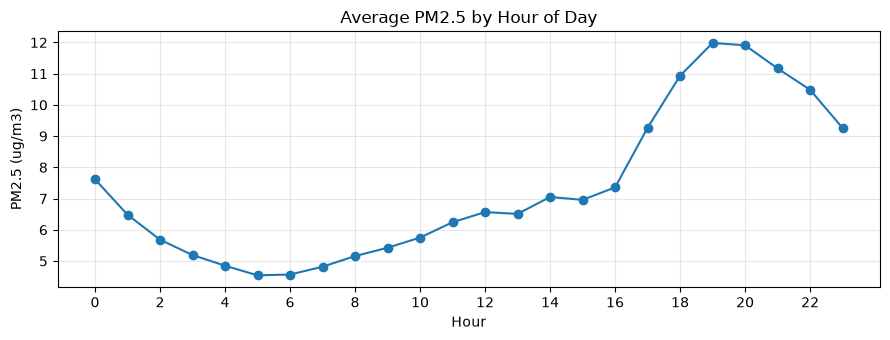

In [5]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

In [7]:
locations = {
    "Connaught Place": (28.6315, 77.2167),
    "Rohini": (28.7495, 77.0565),
    "Dwarka": (28.5921, 77.0460),
    "Saket": (28.5245, 77.2066),
    "Lajpat Nagar": (28.5677, 77.2433),
    "Karol Bagh": (28.6514, 77.1907),
    "Anand Vihar": (28.6469, 77.3160),
    "Vasant Kunj": (28.5293, 77.1541),
    "Noida": (28.5355, 77.3910),
    "Delhi Airport": (28.5562, 77.1000)
}

print("Number of locations:", len(locations))

for name, coords in locations.items():
    print(name, "->", coords)

Number of locations: 10
Connaught Place -> (28.6315, 77.2167)
Rohini -> (28.7495, 77.0565)
Dwarka -> (28.5921, 77.046)
Saket -> (28.5245, 77.2066)
Lajpat Nagar -> (28.5677, 77.2433)
Karol Bagh -> (28.6514, 77.1907)
Anand Vihar -> (28.6469, 77.316)
Vasant Kunj -> (28.5293, 77.1541)
Noida -> (28.5355, 77.391)
Delhi Airport -> (28.5562, 77.1)


In [8]:
end_date = pd.Timestamp.today().normalize() - pd.Timedelta(days=1)
start_date = end_date - pd.Timedelta(days=29)

start_date = start_date.strftime("%Y-%m-%d")
end_date = end_date.strftime("%Y-%m-%d")

print("Start date:", start_date)
print("End date:", end_date)

Start date: 2026-07-18
End date: 2026-08-16


In [9]:
DATA = Path("data")

DATA.mkdir(exist_ok=True)

print("Data folder:", DATA.resolve())

Data folder: C:\Users\USER\ML\Lab-1\data


In [10]:
WEATHER_URL = "https://archive-api.open-meteo.com/v1/archive"

weather_data = []

for location, (latitude, longitude) in locations.items():

    print("Collecting weather data for:", location)

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Asia/Kolkata"
    }

    try:
        response = requests.get(
            WEATHER_URL,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        df = pd.DataFrame(data["hourly"])

        # Add location information
        df["location"] = location
        df["latitude"] = latitude
        df["longitude"] = longitude

        weather_data.append(df)

        print("  ✓", len(df), "records collected")

    except Exception as e:
        print("  ✗ Error:", e)

    # Small delay between requests
    time.sleep(1)

weather_df = pd.concat(weather_data, ignore_index=True)

# Convert time column
weather_df["time"] = pd.to_datetime(weather_df["time"])

print("\nWeather dataset shape:", weather_df.shape)

weather_df.head()

  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected

Weather dataset shape: (7200, 8)


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,location,latitude,longitude
0,2026-07-18 00:00:00,32.2,66,0.0,4.8,Connaught Place,28.6315,77.2167
1,2026-07-18 01:00:00,31.5,67,0.0,3.7,Connaught Place,28.6315,77.2167
2,2026-07-18 02:00:00,31.1,66,0.0,3.7,Connaught Place,28.6315,77.2167
3,2026-07-18 03:00:00,31.0,64,0.0,4.3,Connaught Place,28.6315,77.2167
4,2026-07-18 04:00:00,30.9,62,0.0,6.7,Connaught Place,28.6315,77.2167


In [11]:
weather_file = DATA / "weather.csv"

weather_df.to_csv(
    weather_file,
    index=False
)

print("Weather data saved to:", weather_file)

Weather data saved to: data\weather.csv


In [12]:
AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

air_quality_data = []

for location, (latitude, longitude) in locations.items():

    print("Collecting air-quality data for:", location)

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": (
            "pm2_5,"
            "pm10,"
            "nitrogen_dioxide,"
            "ozone,"
            "sulphur_dioxide,"
            "carbon_monoxide"
        ),
        "timezone": "Asia/Kolkata"
    }

    try:
        response = requests.get(
            AQ_URL,
            params=params,
            timeout=30
        )

        response.raise_for_status()

        data = response.json()

        df = pd.DataFrame(data["hourly"])

        # Add location information
        df["location"] = location
        df["latitude"] = latitude
        df["longitude"] = longitude

        air_quality_data.append(df)

        print("  ✓", len(df), "records collected")

    except Exception as e:
        print("  ✗ Error:", e)

    time.sleep(1)

air_df = pd.concat(
    air_quality_data,
    ignore_index=True
)

air_df["time"] = pd.to_datetime(air_df["time"])

print("\nAir-quality dataset shape:", air_df.shape)

air_df.head()

  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected
  ✗ Error: ('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))
  ✓ 720 records collected
  ✓ 720 records collected
  ✓ 720 records collected

Air-quality dataset shape: (6480, 10)


,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,location,latitude,longitude
0,2026-07-18 00:00:00,197.9,722.7,84.2,0.0,33.1,714.0,Connaught Place,28.6315,77.2167
1,2026-07-18 01:00:00,191.4,646.3,81.2,0.0,32.9,561.0,Connaught Place,28.6315,77.2167
2,2026-07-18 02:00:00,176.0,538.3,76.6,1.0,31.9,435.0,Connaught Place,28.6315,77.2167
3,2026-07-18 03:00:00,155.1,434.0,70.9,3.0,30.0,341.0,Connaught Place,28.6315,77.2167
4,2026-07-18 04:00:00,131.3,349.2,63.6,7.0,27.2,273.0,Connaught Place,28.6315,77.2167


In [13]:
air_file = DATA / "air_quality.csv"

air_df.to_csv(
    air_file,
    index=False
)

print("Air-quality data saved to:", air_file)

Air-quality data saved to: data\air_quality.csv


In [14]:
print("Weather dataset:")
print(weather_df.shape)

print("\nAir-quality dataset:")
print(air_df.shape)

print("\nWeather columns:")
print(weather_df.columns.tolist())

print("\nAir-quality columns:")
print(air_df.columns.tolist())

Weather dataset:
(7200, 8)

Air-quality dataset:
(6480, 10)

Weather columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'location', 'latitude', 'longitude']

Air-quality columns:
['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide', 'location', 'latitude', 'longitude']


In [15]:
final_df = pd.merge(
    weather_df,
    air_df,
    on=[
        "location",
        "latitude",
        "longitude",
        "time"
    ],
    how="inner"
)

print("Final dataset shape:", final_df.shape)

final_df.head()

Final dataset shape: (6480, 14)


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,location,latitude,longitude,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-07-18 00:00:00,32.2,66,0.0,4.8,Connaught Place,28.6315,77.2167,197.9,722.7,84.2,0.0,33.1,714.0
1,2026-07-18 01:00:00,31.5,67,0.0,3.7,Connaught Place,28.6315,77.2167,191.4,646.3,81.2,0.0,32.9,561.0
2,2026-07-18 02:00:00,31.1,66,0.0,3.7,Connaught Place,28.6315,77.2167,176.0,538.3,76.6,1.0,31.9,435.0
3,2026-07-18 03:00:00,31.0,64,0.0,4.3,Connaught Place,28.6315,77.2167,155.1,434.0,70.9,3.0,30.0,341.0
4,2026-07-18 04:00:00,30.9,62,0.0,6.7,Connaught Place,28.6315,77.2167,131.3,349.2,63.6,7.0,27.2,273.0


In [16]:
final_df = final_df.rename(columns={
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "wind_speed_10m": "wind_speed"
})

In [17]:
print(final_df.columns.tolist())

['time', 'temperature', 'humidity', 'precipitation', 'wind_speed', 'location', 'latitude', 'longitude', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']


In [18]:
columns = [
    "location",
    "latitude",
    "longitude",
    "time",
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "carbon_monoxide"
]

final_df = final_df[columns]

print(final_df.head())

          location  latitude  longitude                time  temperature  \
0  Connaught Place   28.6315    77.2167 2026-07-18 00:00:00         32.2   
1  Connaught Place   28.6315    77.2167 2026-07-18 01:00:00         31.5   
2  Connaught Place   28.6315    77.2167 2026-07-18 02:00:00         31.1   
3  Connaught Place   28.6315    77.2167 2026-07-18 03:00:00         31.0   
4  Connaught Place   28.6315    77.2167 2026-07-18 04:00:00         30.9   

   humidity  precipitation  wind_speed  pm2_5   pm10  nitrogen_dioxide  ozone  \
0        66            0.0         4.8  197.9  722.7              84.2    0.0   
1        67            0.0         3.7  191.4  646.3              81.2    0.0   
2        66            0.0         3.7  176.0  538.3              76.6    1.0   
3        64            0.0         4.3  155.1  434.0              70.9    3.0   
4        62            0.0         6.7  131.3  349.2              63.6    7.0   

   sulphur_dioxide  carbon_monoxide  
0             33.1

In [19]:
print("Missing values in each column:")
print(final_df.isna().sum())

Missing values in each column:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64


In [20]:
print("Number of duplicate rows:", final_df.duplicated().sum())

Number of duplicate rows: 0


In [21]:
numeric_columns = [
    "temperature",
    "humidity",
    "precipitation",
    "wind_speed",
    "pm2_5",
    "pm10",
    "nitrogen_dioxide",
    "ozone",
    "sulphur_dioxide",
    "carbon_monoxide"
]

print("Negative values:")
print((final_df[numeric_columns] < 0).sum())

Negative values:
temperature         0
humidity            0
precipitation       0
wind_speed          0
pm2_5               0
pm10                0
nitrogen_dioxide    0
ozone               0
sulphur_dioxide     0
carbon_monoxide     0
dtype: int64


In [22]:
final_file = DATA / "delhi_air_quality_weather.csv"

final_df.to_csv(
    final_file,
    index=False
)

print("Final dataset saved to:")
print(final_file.resolve())

print("\nFinal dataset shape:")
print(final_df.shape)

Final dataset saved to:
C:\Users\USER\ML\Lab-1\data\delhi_air_quality_weather.csv

Final dataset shape:
(6480, 14)


In [23]:
avg_pm25 = (
    final_df
    .groupby("location")["pm2_5"]
    .mean()
    .sort_values(ascending=False)
)

print("Average PM2.5 by location:")
print(avg_pm25)

Average PM2.5 by location:
location
Connaught Place    53.633056
Karol Bagh         53.633056
Rohini             53.633056
Dwarka             48.818056
Delhi Airport      48.818056
Lajpat Nagar       48.818056
Noida              48.818056
Saket              48.818056
Vasant Kunj        48.818056
Name: pm2_5, dtype: float64


In [24]:
highest_location = avg_pm25.index[0]
highest_value = avg_pm25.iloc[0]

print("\nLocation with highest average PM2.5:")
print(highest_location)

print("Average PM2.5:",
      round(highest_value, 2),
      "µg/m³")


Location with highest average PM2.5:
Connaught Place
Average PM2.5: 53.63 µg/m³


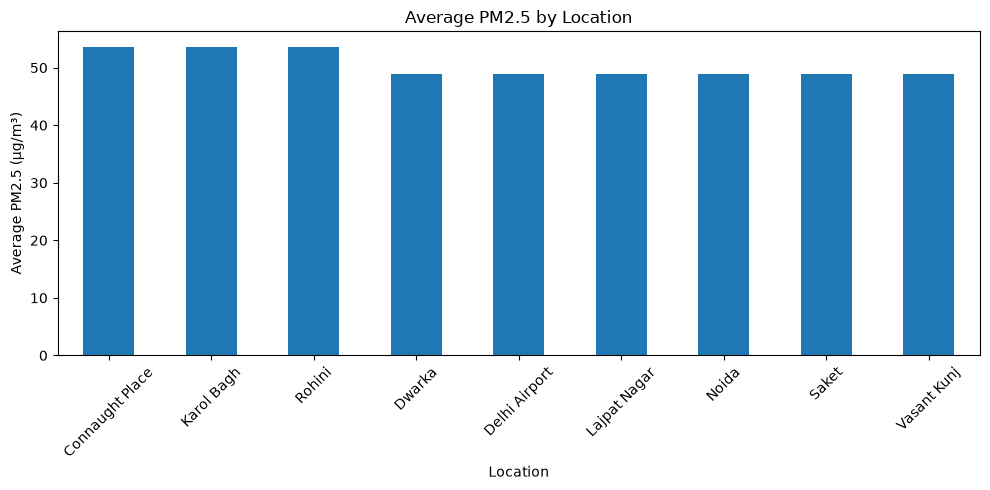

In [25]:
plt.figure(figsize=(10, 5))

avg_pm25.plot(
    kind="bar"
)

plt.title("Average PM2.5 by Location")
plt.xlabel("Location")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
weather_pollution = final_df[
    [
        "temperature",
        "humidity",
        "precipitation",
        "wind_speed",
        "pm2_5"
    ]
]

correlation = weather_pollution.corr()

print(correlation["pm2_5"].sort_values())

humidity        -0.243828
wind_speed      -0.177262
precipitation   -0.125190
temperature      0.277760
pm2_5            1.000000
Name: pm2_5, dtype: float64


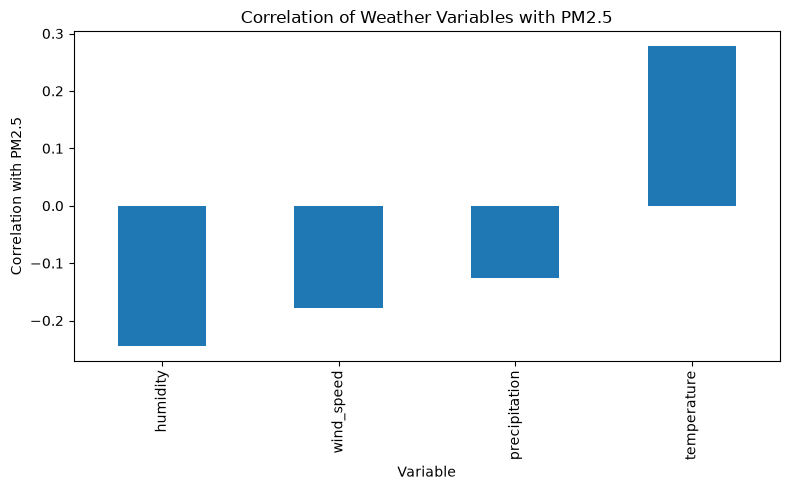

In [27]:
plt.figure(figsize=(8, 5))

correlation["pm2_5"].drop("pm2_5").sort_values().plot(
    kind="bar"
)

plt.title("Correlation of Weather Variables with PM2.5")
plt.xlabel("Variable")
plt.ylabel("Correlation with PM2.5")

plt.tight_layout()
plt.show()

In [28]:
print("Files collected in this lab:\n")

for f in sorted(DATA.glob("*")):
    print(
        f"{f.name:35s} "
        f"{f.stat().st_size:>10,} bytes"
    )

Files collected in this lab:

.ipynb_checkpoints                           0 bytes
air_quality.csv                        507,067 bytes
delhi_air_quality_weather.csv          612,205 bytes
House.html                           1,774,801 bytes
Magicbrick.html                      1,502,328 bytes
Magicbrick_files                             0 bytes
weather.csv                            453,810 bytes


In [1]:
import requests
from bs4 import BeautifulSoup

In [5]:
url = "https://books.toscrape.com/"
books = []
while url:
    response = requests.get(url)
    if response.status_code != 200:
        print("Failed to access:", url)
        break
    soup = BeautifulSoup(response.text, "html.parser")
    book_list = soup.find_all("article", class_="product_pod")

    for book in book_list:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.find("p", class_="star-rating")["class"][1]
        books.append({
            "title": title,
            "price": price,
            "rating": rating
        })
    next_page = soup.find("li", class_="next")

    if next_page:
        next_link = next_page.a["href"]
        if "catalogue/" in url:
            url = url.rsplit("/", 1)[0] + "/" + next_link
        else:
            url = url + next_link
    else:
        url = None
print("Total books collected:", len(books))
for book in books[:10]:
    print(book)

Total books collected: 1000
{'title': 'A Light in the Attic', 'price': 'Â£51.77', 'rating': 'Three'}
{'title': 'Tipping the Velvet', 'price': 'Â£53.74', 'rating': 'One'}
{'title': 'Soumission', 'price': 'Â£50.10', 'rating': 'One'}
{'title': 'Sharp Objects', 'price': 'Â£47.82', 'rating': 'Four'}
{'title': 'Sapiens: A Brief History of Humankind', 'price': 'Â£54.23', 'rating': 'Five'}
{'title': 'The Requiem Red', 'price': 'Â£22.65', 'rating': 'One'}
{'title': 'The Dirty Little Secrets of Getting Your Dream Job', 'price': 'Â£33.34', 'rating': 'Four'}
{'title': 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'price': 'Â£17.93', 'rating': 'Three'}
{'title': 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'price': 'Â£22.60', 'rating': 'Four'}
{'title': 'The Black Maria', 'price': 'Â£52.15', 'rating': 'One'}


In [7]:
import pandas as pd
books_df = pd.DataFrame(books)
books_df.to_csv("books_data.csv", index=False)
print("Book data saved successfully to books_data.csv")

Book data saved successfully to books_data.csv
